# RetailRocket chronological split preparation

The notebook applies a per-user chronological splitting strategy in which interactions are first ordered by user and timestamp, then divided into training, validation, and test sets using a 70/15/15 temporal allocation. Earlier interactions are assigned to training, intermediate interactions to validation, and the most recent interactions to test, with safeguards for users with very short histories. After split assignment, interactions are aggregated within each split only, preventing future information from leaking into training. The validation and test sets are then restricted to users and items observed in training, and previously seen training pairs are removed, producing leakage-safe pre-split files suitable for RecBole ItemKNN.

The notebook prepares the **fixed train / valid / test chronological split** first.
It writes:
- split diagnostics tables
- split diagnostic figures
- pre-split RecBole `.inter` files

Run this notebook before the ItemKNN notebook.

Please use python version 3.12.10


In [1]:
!python --version
%pip install -q pandas numpy matplotlib


Python 3.12.10
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Configuration and paths


In [ ]:
# Define the RecBole dataset name used for the chronological ItemKNN pipeline.
DATASET_NAME = "retailrocket_itemknn_chrono"

# Assign relative interaction strengths for implicit-feedback modelling.
WEIGHT_MAP = {
    "view": 1.0,
    "addtocart": 3.0,
    "transaction": 5.0,
}

# Set the per-user chronological split proportions.
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15

# Resolve the current working directory as the project root.
PROJECT_ROOT = Path.cwd()

# Define the main input and output directory structure.
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output" / "retailrocket_itemknn_chronological"

# Define subdirectories for figures, tables, prepared splits, and the
# RecBole-formatted dataset.
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
PREPARED_DIR = OUTPUT_DIR / "prepared_splits"
RECOBOLE_ROOT = OUTPUT_DIR / "recbole_dataset"
DATASET_DIR = RECOBOLE_ROOT / DATASET_NAME

# Define file paths for the required raw RetailRocket inputs.
EVENTS_PATH = INPUT_DIR / "events.csv"
CATEGORY_TREE_PATH = INPUT_DIR / "category_tree.csv"
ITEM_PROPERTIES_PART1_PATH = INPUT_DIR / "item_properties_part1.csv"
ITEM_PROPERTIES_PART2_PATH = INPUT_DIR / "item_properties_part2.csv"

# Create the output directories if they do not already exist.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PREPARED_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Stop execution early if the main events file is missing.
if not EVENTS_PATH.exists():
    raise FileNotFoundError(f"Could not find events file: {EVENTS_PATH}")

# Print key resolved paths for verification and debugging.
print("Project root:", PROJECT_ROOT)
print("Input dir:", INPUT_DIR)
print("Output dir:", OUTPUT_DIR)
print("Prepared split dir:", PREPARED_DIR)
print("RecBole dataset dir:", DATASET_DIR)
print("Events path:", EVENTS_PATH)

Project root: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project
Input dir: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\input
Output dir: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn_chronological
Prepared split dir: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn_chronological\prepared_splits
RecBole dataset dir: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\output\retailrocket_itemknn_chronological\recbole_dataset\retailrocket_itemknn_chrono
Events path: e:\UWE\Class Notes\Year 3\Advanced AI\Group Project\Task 1\Oishik\project\input\events.csv


## 2. Load the raw events


In [ ]:
# Load the core event interaction file with only the columns required for
# chronological splitting and ItemKNN preparation.
events = pd.read_csv(
    EVENTS_PATH,
    usecols=["timestamp", "visitorid", "event", "itemid"],
    dtype={"visitorid": "int64", "itemid": "int64"},
)

# Convert Unix millisecond timestamps to timezone-aware UTC datetimes.
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms", utc=True)

# Store event labels as string values for consistent downstream handling.
events["event"] = events["event"].astype("string")

# Assign an event priority so ties at the same timestamp can be ordered
# consistently by interaction strength.
events["event_priority"] = (
    events["event"]
    .map({"view": 0, "addtocart": 1, "transaction": 2})
    .fillna(99)
    .astype(int)
)

# Map each event type to its implicit-feedback weight.
events["weight"] = events["event"].map(WEIGHT_MAP).astype(np.float32)

# Print the basic shape of the loaded interaction dataset.
print("Raw rows:", len(events))
print("Unique visitors:", events["visitorid"].nunique())
print("Unique items:", events["itemid"].nunique())

# Preview the first few loaded event records.
display(events.head())

# Display the event-type frequency distribution.
display(events["event"].value_counts(dropna=False).rename_axis("event").to_frame("count"))

Raw rows: 2756101
Unique visitors: 1407580
Unique items: 235061


,timestamp,visitorid,event,itemid,event_priority,weight
0,2015-06-02 05:02:12.117000+00:00,257597,view,355908,0,1.0
1,2015-06-02 05:50:14.164000+00:00,992329,view,248676,0,1.0
2,2015-06-02 05:13:19.827000+00:00,111016,view,318965,0,1.0
3,2015-06-02 05:12:35.914000+00:00,483717,view,253185,0,1.0
4,2015-06-02 05:02:17.106000+00:00,951259,view,367447,0,1.0


,count
event,
view,2664312
addtocart,69332
transaction,22457


## 3. Chronological split labels


In [ ]:
def chronological_split_labels(
    df: pd.DataFrame,
    train_ratio: float = 0.70,
    valid_ratio: float = 0.15,
) -> pd.Series:
    """
    Assign chronological train, validation, and test labels per visitor.

    Interactions are first ordered within each visitor by timestamp,
    event priority, and item identifier. Split labels are then allocated
    so earlier interactions remain in training and later interactions are
    reserved for validation and test where possible.

    Args:
        df: Interaction table containing at least ``visitorid``,
            ``timestamp``, ``event_priority``, and ``itemid``.
        train_ratio: Proportion of each visitor history assigned to the
            training split.
        valid_ratio: Proportion of each visitor history assigned to the
            validation split.

    Returns:
        A series of split labels aligned to the original DataFrame index.
    """
    # Order each visitor history deterministically before split assignment.
    ordered = df.sort_values(
        ["visitorid", "timestamp", "event_priority", "itemid"]
    ).copy()

    def label_user(group: pd.DataFrame) -> pd.Series:
        """
        Label one visitor's ordered interaction history.

        Short histories are handled explicitly to ensure a valid split,
        while longer histories are divided using the requested ratios with
        safeguards to preserve at least one test interaction.

        Args:
            group: Ordered interaction history for a single visitor.

        Returns:
            A series of split labels indexed to the group's rows.
        """
        n = len(group)

        # Handle very short histories with fixed split assignments.
        if n == 1:
            labels = ["train"]
        elif n == 2:
            labels = ["train", "test"]
        else:
            # Compute initial split sizes from the requested proportions.
            train_n = max(1, int(np.floor(n * train_ratio)))
            valid_n = max(1, int(np.floor(n * valid_ratio)))
            test_n = n - train_n - valid_n

            # Rebalance counts if no test interactions remain.
            if test_n < 1:
                if valid_n > 1:
                    valid_n -= 1
                elif train_n > 1:
                    train_n -= 1
                test_n = n - train_n - valid_n

            # Apply a final safeguard to preserve train, validation, and
            # test partitions where possible.
            if test_n < 1:
                train_n = max(1, n - 2)
                valid_n = 1
                test_n = n - train_n - valid_n

            # Construct ordered split labels for the visitor history.
            labels = (
                ["train"] * train_n
                + ["valid"] * valid_n
                + ["test"] * test_n
            )

        return pd.Series(labels, index=group.index)

    # Apply split assignment independently to each visitor history.
    split_labels = ordered.groupby("visitorid", group_keys=False).apply(
        label_user
    )

    # Realign the generated labels to the original row order.
    return split_labels.reindex(df.index)

## 4. Apply the split and save diagnostics


In [ ]:
# Create a working copy of the event table for split assignment.
split_events = events.copy()

# Assign chronological train, validation, and test labels per visitor.
split_events["split"] = chronological_split_labels(
    split_events,
    train_ratio=TRAIN_RATIO,
    valid_ratio=VALID_RATIO,
)

# Summarise row counts, entity counts, and time ranges for each split.
chronological_split_summary = (
    split_events.groupby("split")
    .agg(
        rows=("visitorid", "size"),
        unique_users=("visitorid", "nunique"),
        unique_items=("itemid", "nunique"),
        start_timestamp_utc=("timestamp", "min"),
        end_timestamp_utc=("timestamp", "max"),
    )
    .reset_index()
)

# Count event types within each split.
split_event_type_counts = (
    split_events.groupby(["split", "event"]).size().reset_index(name="count")
    .pivot(index="split", columns="event", values="count")
    .fillna(0)
    .reset_index()
)

# Collect the training-set users and items for unseen-entity checks.
train_users = set(
    split_events.loc[split_events["split"] == "train", "visitorid"].unique()
)
train_items = set(
    split_events.loc[split_events["split"] == "train", "itemid"].unique()
)

# Prepare row-wise diagnostics for validation and test mapping behaviour.
mapping_rows = []

for split_name in ["valid", "test"]:
    # Isolate the current holdout split.
    part = split_events.loc[split_events["split"] == split_name].copy()

    # Identify users and items not observed in the training split.
    unseen_user_mask = ~part["visitorid"].isin(train_users)
    unseen_item_mask = ~part["itemid"].isin(train_items)

    # Mark rows that would be retained after train-only ID mapping.
    retained_mask = ~(unseen_user_mask | unseen_item_mask)

    # Record entity-level and row-level mapping diagnostics.
    mapping_rows.append(
        {
            "split": split_name,
            "rows": int(len(part)),
            "unique_users": int(part["visitorid"].nunique()),
            "unique_items": int(part["itemid"].nunique()),
            "unseen_users": int(part.loc[unseen_user_mask, "visitorid"].nunique()),
            "unseen_items": int(part.loc[unseen_item_mask, "itemid"].nunique()),
            "rows_with_unseen_user": int(unseen_user_mask.sum()),
            "rows_with_unseen_item": int(unseen_item_mask.sum()),
            "retained_rows_after_train_mapping": int(retained_mask.sum()),
            "dropped_rows_after_train_mapping": int((~retained_mask).sum()),
            "retained_pct_after_train_mapping": float(retained_mask.mean() * 100),
        }
    )

# Convert mapping diagnostics into a tabular summary.
split_mapping_diagnostics = pd.DataFrame(mapping_rows)

# Save the split summary table.
chronological_split_summary.to_csv(
    TABLE_DIR / f"{DATASET_NAME}_chronological_split_summary.csv",
    index=False,
)

# Save per-split event-type counts.
split_event_type_counts.to_csv(
    TABLE_DIR / f"{DATASET_NAME}_split_event_type_counts.csv",
    index=False,
)

# Save train-only mapping diagnostics for holdout splits.
split_mapping_diagnostics.to_csv(
    TABLE_DIR / f"{DATASET_NAME}_split_mapping_diagnostics.csv",
    index=False,
)

# Display the main split summary outputs.
display(chronological_split_summary)
display(split_event_type_counts)
display(split_mapping_diagnostics)

,split,rows,unique_users,unique_items,start_timestamp_utc,end_timestamp_utc
0,test,513257,406020,114068,2015-05-03 03:00:29.427000+00:00,2015-09-18 02:59:47.788000+00:00
1,train,1990913,1407580,220008,2015-05-03 03:00:04.384000+00:00,2015-09-18 02:59:41.778000+00:00
2,valid,251931,200028,72821,2015-05-03 03:00:26.228000+00:00,2015-09-18 02:57:55.667000+00:00


event,split,addtocart,transaction,view
0,test,16963,9960,486334
1,train,39257,8727,1942929
2,valid,13112,3770,235049


,split,rows,unique_users,unique_items,unseen_users,unseen_items,rows_with_unseen_user,rows_with_unseen_item,retained_rows_after_train_mapping,dropped_rows_after_train_mapping,retained_pct_after_train_mapping
0,valid,251931,200028,72821,0,4994,0,5423,246508,5423,97.847426
1,test,513257,406020,114068,0,11357,0,12754,500503,12754,97.515085


## 5. Save split diagnostic figures


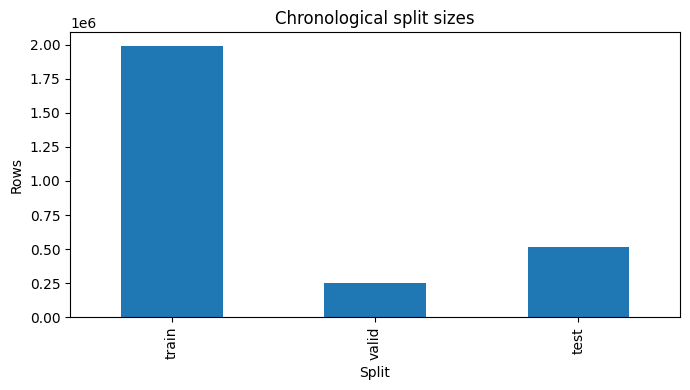

In [ ]:
# Define the presentation order for the train, validation, and test splits.
split_order = ["train", "valid", "test"]

# Extract split sizes in the desired display order.
split_size_plot = (
    chronological_split_summary.set_index("split")
    .reindex(split_order)["rows"]
)

# Plot the number of rows in each chronological split.
plt.figure(figsize=(7, 4))
split_size_plot.plot(kind="bar")
plt.title("Chronological split sizes")
plt.xlabel("Split")
plt.ylabel("Rows")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "chronological_split_sizes.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Aggregate inside each split

This avoids leaking future interactions into training aggregates.


In [ ]:
def aggregate_split_events(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """
    Aggregate event-level interactions for a single split to user-item level.

    Interaction weights are summed per user-item pair, while the most recent
    timestamp is retained. Identifier columns are then renamed and converted
    to the string-based format expected by downstream RecBole processing.

    Args:
        df: Event-level interaction table containing split labels, weights,
            timestamps, visitor identifiers, and item identifiers.
        split_name: Name of the split to aggregate.

    Returns:
        A DataFrame containing aggregated user-item interactions with
        ``user_id``, ``item_id``, ``rating``, and ``timestamp`` columns.
    """
    # Select only rows belonging to the requested split.
    part = df.loc[df["split"] == split_name].copy()

    # Aggregate to one row per user-item pair, summing interaction weight and
    # retaining the most recent timestamp.
    out = (
        part.groupby(["visitorid", "itemid"], as_index=False)
        .agg(
            rating=("weight", "sum"),
            timestamp=("timestamp", "max"),
        )
        .rename(columns={"visitorid": "user_id", "itemid": "item_id"})
    )

    # Convert user and item identifiers to string tokens for RecBole.
    out["user_id"] = out["user_id"].astype(str)
    out["item_id"] = out["item_id"].astype(str)

    # Store the aggregated interaction strength as float32.
    out["rating"] = out["rating"].astype(np.float32)

    # Convert timestamps to Unix seconds for export compatibility.
    out["timestamp"] = (out["timestamp"].astype("int64") // 10**9).astype(
        np.float64
    )

    return out


# Aggregate each chronological split to user-item interaction level.
train_interactions = aggregate_split_events(split_events, "train")
valid_interactions = aggregate_split_events(split_events, "valid")
test_interactions = aggregate_split_events(split_events, "test")

# Collect training-set users, items, and observed user-item pairs for
# downstream holdout filtering.
train_users_str = set(train_interactions["user_id"].unique())
train_items_str = set(train_interactions["item_id"].unique())
train_pairs = set(zip(train_interactions["user_id"], train_interactions["item_id"]))


def restrict_holdout(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Restrict a holdout split to train-mappable, previously unseen pairs.

    Rows are retained only when both the user and item were observed in the
    training split and the exact user-item pair was not already present in
    training. Dropped rows are labelled with a reason for exclusion.

    Args:
        df: Aggregated holdout interaction table containing ``user_id`` and
            ``item_id`` columns.

    Returns:
        A tuple containing:
            - the retained holdout rows
            - the dropped holdout rows with a ``drop_reason`` column
    """
    # Keep only rows whose users and items both exist in training.
    base_mask = df["user_id"].isin(train_users_str) & df["item_id"].isin(
        train_items_str
    )

    # Identify holdout rows whose exact user-item pairs were already observed
    # in the training split.
    pair_seen_mask = pd.Series(
        list(zip(df["user_id"], df["item_id"])),
        index=df.index,
    ).isin(train_pairs)

    # Retain only train-mappable rows that are not previously seen pairs.
    keep_mask = base_mask & ~pair_seen_mask

    # Split the holdout table into retained and dropped rows.
    kept = df.loc[keep_mask].copy()
    dropped = df.loc[~keep_mask].copy()

    # Record the reason each dropped row was excluded.
    dropped["drop_reason"] = np.select(
        [
            ~base_mask.loc[dropped.index],
            pair_seen_mask.loc[dropped.index],
        ],
        [
            "unknown_user_or_item_vs_train",
            "seen_train_pair",
        ],
        default="other",
    )

    return kept, dropped


# Apply holdout restrictions to the validation and test interaction tables.
valid_interactions_kept, valid_interactions_dropped = restrict_holdout(
    valid_interactions
)
test_interactions_kept, test_interactions_dropped = restrict_holdout(
    test_interactions
)

# Summarise the number of aggregated, retained, and dropped rows per split.
holdout_filter_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "aggregated_rows": int(len(train_interactions)),
            "kept_rows": int(len(train_interactions)),
            "dropped_rows": 0,
        },
        {
            "split": "valid",
            "aggregated_rows": int(len(valid_interactions)),
            "kept_rows": int(len(valid_interactions_kept)),
            "dropped_rows": int(len(valid_interactions_dropped)),
        },
        {
            "split": "test",
            "aggregated_rows": int(len(test_interactions)),
            "kept_rows": int(len(test_interactions_kept)),
            "dropped_rows": int(len(test_interactions_dropped)),
        },
    ]
)

# Save the holdout filtering summary table.
holdout_filter_summary.to_csv(
    TABLE_DIR / f"{DATASET_NAME}_holdout_filter_summary.csv",
    index=False,
)

# Display the holdout filtering summary.
display(holdout_filter_summary)

,split,aggregated_rows,kept_rows,dropped_rows
0,train,1743817,1743817,0
1,valid,234169,131735,102434
2,test,475094,273872,201222


## 7. Write prepared CSVs and RecBole atomic files


In [ ]:
# Save the aggregated train, validation, and test interaction tables as CSV
# files for inspection and reuse.
train_interactions.to_csv(PREPARED_DIR / "train_interactions.csv", index=False)
valid_interactions_kept.to_csv(PREPARED_DIR / "valid_interactions.csv", index=False)
test_interactions_kept.to_csv(PREPARED_DIR / "test_interactions.csv", index=False)

# Save the dropped validation and test rows for diagnostics.
valid_interactions_dropped.to_csv(
    PREPARED_DIR / "valid_interactions_dropped.csv",
    index=False,
)
test_interactions_dropped.to_csv(
    PREPARED_DIR / "test_interactions_dropped.csv",
    index=False,
)


def to_atomic(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert an aggregated interaction table to RecBole atomic format.

    The required RecBole field suffixes are applied to the column names, and
    only the columns needed for interaction loading are retained.

    Args:
        df: Aggregated interaction table containing ``user_id``, ``item_id``,
            ``rating``, and ``timestamp`` columns.

    Returns:
        A DataFrame formatted for RecBole ``.inter`` file export.
    """
    return df.rename(
        columns={
            "user_id": "user_id:token",
            "item_id": "item_id:token",
            "rating": "rating:float",
            "timestamp": "timestamp:float",
        }
    )[["user_id:token", "item_id:token", "rating:float", "timestamp:float"]]


# Convert each split to RecBole atomic interaction format.
train_atomic = to_atomic(train_interactions)
valid_atomic = to_atomic(valid_interactions_kept)
test_atomic = to_atomic(test_interactions_kept)

# Define output paths for the RecBole interaction files.
train_path = DATASET_DIR / f"{DATASET_NAME}.train.inter"
valid_path = DATASET_DIR / f"{DATASET_NAME}.valid.inter"
test_path = DATASET_DIR / f"{DATASET_NAME}.test.inter"

# Write the atomic interaction files using tab-separated format.
train_atomic.to_csv(train_path, sep="\t", index=False)
valid_atomic.to_csv(valid_path, sep="\t", index=False)
test_atomic.to_csv(test_path, sep="\t", index=False)

# Build a simple manifest of the generated split files and their row counts.
split_file_manifest = pd.DataFrame(
    [
        {
            "name": "train_interactions_csv",
            "path": str(PREPARED_DIR / "train_interactions.csv"),
            "rows": len(train_interactions),
        },
        {
            "name": "valid_interactions_csv",
            "path": str(PREPARED_DIR / "valid_interactions.csv"),
            "rows": len(valid_interactions_kept),
        },
        {
            "name": "test_interactions_csv",
            "path": str(PREPARED_DIR / "test_interactions.csv"),
            "rows": len(test_interactions_kept),
        },
        {
            "name": "train_atomic_inter",
            "path": str(train_path),
            "rows": len(train_atomic),
        },
        {
            "name": "valid_atomic_inter",
            "path": str(valid_path),
            "rows": len(valid_atomic),
        },
        {
            "name": "test_atomic_inter",
            "path": str(test_path),
            "rows": len(test_atomic),
        },
    ]
)

# Save the split file manifest for traceability.
split_file_manifest.to_csv(
    TABLE_DIR / f"{DATASET_NAME}_split_file_manifest.csv",
    index=False,
)

# Display the manifest and confirm successful file generation.
display(split_file_manifest)
print("Prepared split files written successfully.")

,name,path,rows
0,train_interactions_csv,e:\UWE\Class Notes\Year 3\Advanced AI\Group Pr...,1743817
1,valid_interactions_csv,e:\UWE\Class Notes\Year 3\Advanced AI\Group Pr...,131735
2,test_interactions_csv,e:\UWE\Class Notes\Year 3\Advanced AI\Group Pr...,273872
3,train_atomic_inter,e:\UWE\Class Notes\Year 3\Advanced AI\Group Pr...,1743817
4,valid_atomic_inter,e:\UWE\Class Notes\Year 3\Advanced AI\Group Pr...,131735
5,test_atomic_inter,e:\UWE\Class Notes\Year 3\Advanced AI\Group Pr...,273872


Prepared split files written successfully.
